# 🏏 IPL 2024 Analytics Dashboard — Data Cleaning & EDA
**Author:** Nakul Adhave  
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Data Source:** Kaggle IPL Dataset (matches.csv + deliveries.csv)


## 📊 Dashboard Charts

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")

matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")
m24 = matches[matches['season'] == '2024'].copy()
d24 = deliveries[deliveries['match_id'].isin(m24['id'].tolist())].copy()

print(f"✅ Data loaded — {len(m24)} matches | {len(d24)} deliveries")

✅ Data loaded — 71 matches | 17103 deliveries


### Chart 1 — Team Wins

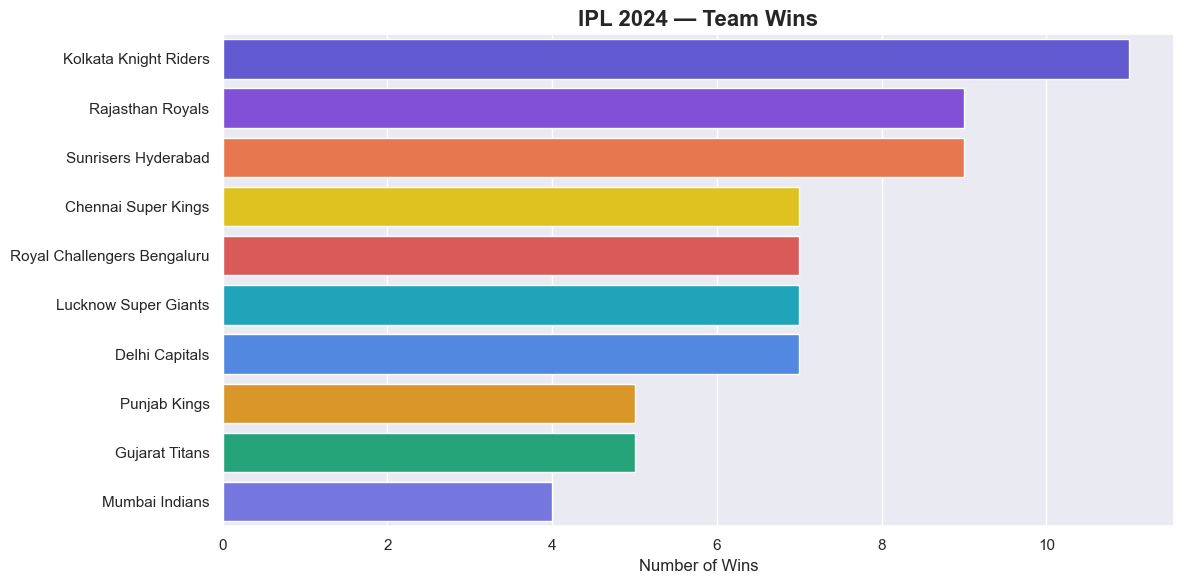

In [48]:
team_wins = m24['winner'].value_counts().reset_index()
team_wins.columns = ['Team', 'Wins']

colors = ['#4f46e5','#7c3aed','#FF6B35','#FFD700','#ef4444',
          '#06b6d4','#3b82f6','#f59e0b','#10b981','#6366f1']

plt.figure(figsize=(12, 6))
sns.barplot(data=team_wins, y='Team', x='Wins', hue='Team', palette=colors, legend=False)
plt.title('IPL 2024 — Team Wins', fontsize=16, fontweight='bold')
plt.xlabel('Number of Wins')
plt.ylabel('')
plt.tight_layout()
plt.savefig('team_wins.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 2 — Top 10 Batsmen

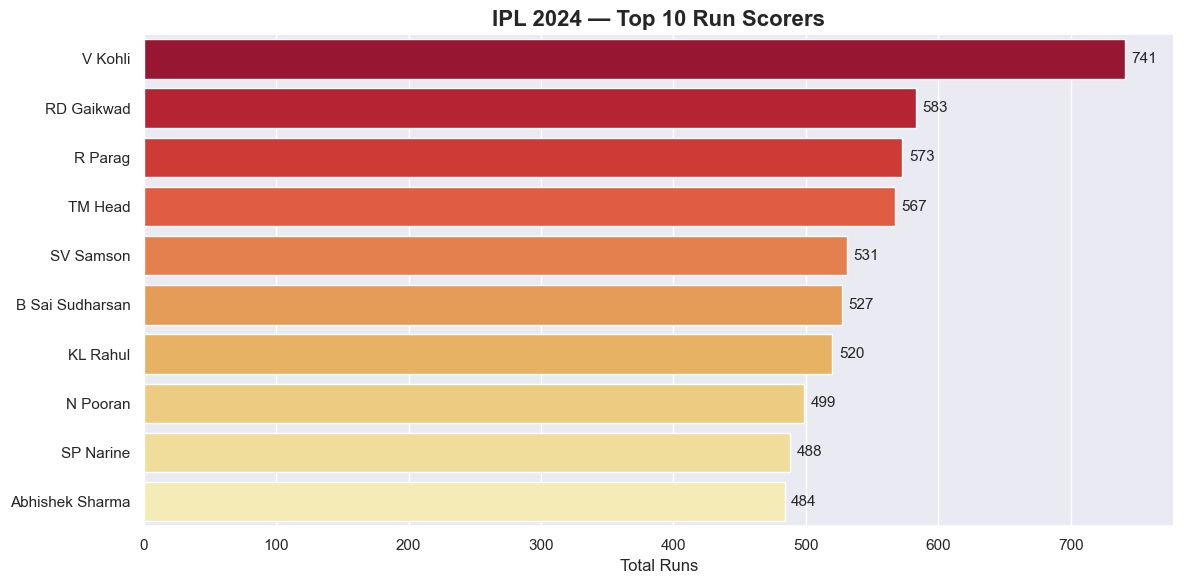

In [49]:
top_bat = d24.groupby('batter')['batsman_runs'].sum().reset_index()
top_bat.columns = ['Batter', 'Runs']
top_bat = top_bat.sort_values('Runs', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_bat, x='Runs', y='Batter', hue='Batter', palette='YlOrRd_r', legend=False)
plt.title('IPL 2024 — Top 10 Run Scorers', fontsize=16, fontweight='bold')
plt.xlabel('Total Runs')
plt.ylabel('')
for i, row in enumerate(top_bat.itertuples()):
    plt.text(row.Runs + 5, i, str(row.Runs), va='center', fontsize=11)
plt.tight_layout()
plt.savefig('top_batsmen.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 3 — Top 10 Bowlers

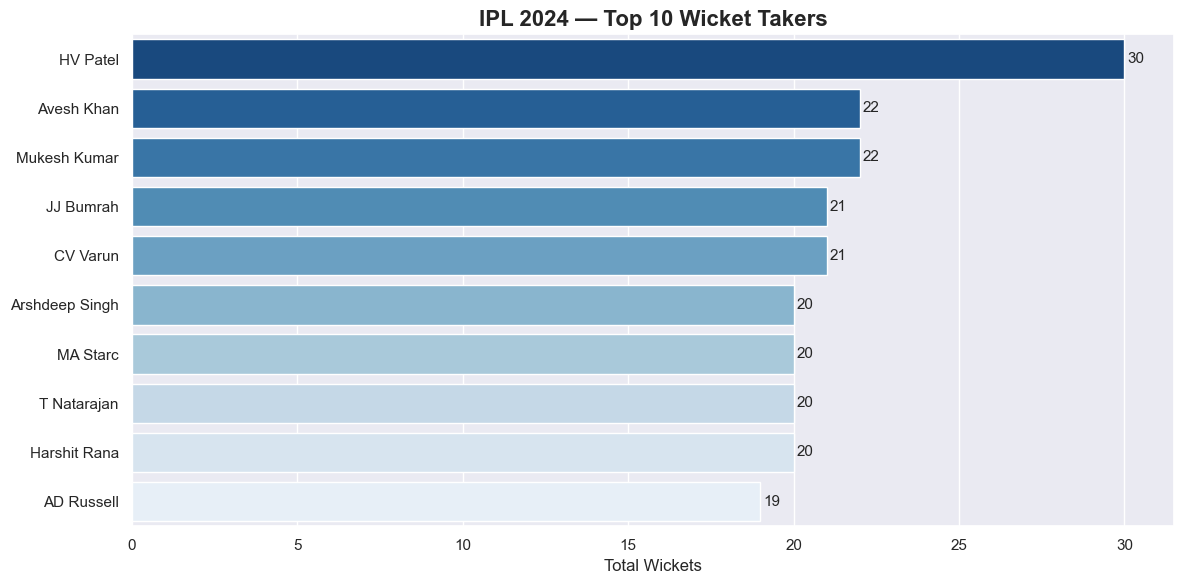

In [50]:
top_bowl = d24[d24['is_wicket'] == 1].groupby('bowler')['is_wicket'].count().reset_index()
top_bowl.columns = ['Bowler', 'Wickets']
top_bowl = top_bowl.sort_values('Wickets', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_bowl, x='Wickets', y='Bowler', hue='Bowler', palette='Blues_r', legend=False)
plt.title('IPL 2024 — Top 10 Wicket Takers', fontsize=16, fontweight='bold')
plt.xlabel('Total Wickets')
plt.ylabel('')
for i, row in enumerate(top_bowl.itertuples()):
    plt.text(row.Wickets + 0.1, i, str(row.Wickets), va='center', fontsize=11)
plt.tight_layout()
plt.savefig('top_bowlers.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 4 — Toss Decision Split

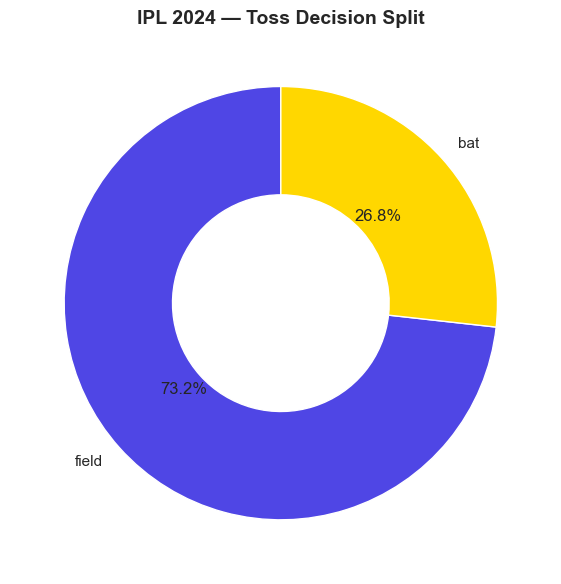

In [51]:
toss = m24['toss_decision'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(toss.values, labels=toss.index, autopct='%1.1f%%',
        colors=['#4f46e5', '#FFD700'], startangle=90,
        wedgeprops={'width': 0.5})
plt.title('IPL 2024 — Toss Decision Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('toss_decision.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔍 Data Analysis & Cleaning

### 1. Dataset Shape

In [52]:
print(f"Matches dataset: {matches.shape}")
print(f"Deliveries dataset: {deliveries.shape}")
print(f"\nIPL 2024 Matches: {len(m24)}")
print(f"IPL 2024 Deliveries: {len(d24)}")

Matches dataset: (1095, 20)
Deliveries dataset: (260920, 17)

IPL 2024 Matches: 71
IPL 2024 Deliveries: 17103


### 2. Matches — First Look

In [53]:
matches.head(3)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar


### 3. Deliveries — First Look

In [54]:
deliveries.head(3)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN


### 4. Missing Values

In [55]:
print("=== MATCHES ===")
print(matches.isnull().sum())
print("\n=== DELIVERIES ===")
print(deliveries.isnull().sum())

=== MATCHES ===
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

=== DELIVERIES ===
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

### 5. Available Seasons

In [56]:
print("Seasons:", sorted(matches['season'].unique()))

Seasons: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']


### 6. Export to Excel

In [57]:
with pd.ExcelWriter('IPL_2024_Dashboard_Data.xlsx') as writer:
    m24.to_excel(writer, sheet_name='Matches', index=False)
    d24.to_excel(writer, sheet_name='Deliveries', index=False)
    team_wins.to_excel(writer, sheet_name='Team_Wins', index=False)
    top_bat.to_excel(writer, sheet_name='Top_Batsmen', index=False)
    top_bowl.to_excel(writer, sheet_name='Top_Bowlers', index=False)

print("✅ Excel exported!")
print(f"\n🏆 Champions: {team_wins.iloc[0]['Team']} — {team_wins.iloc[0]['Wins']} wins")
print(f"🏅 Orange Cap: {top_bat.iloc[0]['Batter']} — {top_bat.iloc[0]['Runs']} runs")
print(f"🎯 Purple Cap: {top_bowl.iloc[0]['Bowler']} — {top_bowl.iloc[0]['Wickets']} wickets")

✅ Excel exported!

🏆 Champions: Kolkata Knight Riders — 11 wins
🏅 Orange Cap: V Kohli — 741 runs
🎯 Purple Cap: HV Patel — 30 wickets
